# Freuqency analysis of CD4 T clusters in TEA-Seq dataset

- related to Fig. 6B & S12A


# Setup


In [2]:
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("dplyr")
quiet_library("rstatix")
quiet_library("data.table")

In [3]:
# define working path
data_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243"
meta_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/meta_data"
output_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/cd4_t/atac"
fig_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243/cd4t_cells/Plots"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "PreRA_teaseq_cd4_t_atac"

In [4]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#5AAA46", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [5]:
#' @title \code{GetClusterFreq}
#'
#' @description \code{GetClusterFreq} calculate the freuqency table from a seurat obejct
#'
#' @param so a seurat or ArchR object
#' @param cluster_name column in the metadata to specify cluster column
#' @param meta_cols column in the metadata to add in the result table
#' @param sample_col default=pbmc_sample_id, column in the metadata to specify sample id
#' @param totalcounts default=NULL, column in the metadata to specify total cell counts per sample. useful when the seurat object is a subset object and want to calcualte frenquency of total
#'
#' @return freq_table a frquency table
#' @exmaple ra_b_cluster_freq <- GetClusterFreq(ra_b_so,
#     cluster_name='SCT_snn_res.0.5',
#     meta_cols = c('subject.subjectGuid','cohort'),
#     totalcounts='cell_counts')
# get frequency of the clusters
GetClusterFreq <- function(so, cluster_name, meta_cols, sample_col = "pbmc_sample_id", totalcounts = NULL) {
  # plot the frequency by sample for l1 adt clustering
  if (class(so) == "Seurat") {
    meta <- so@meta.data %>% as_tibble()
  } else if (class(so) == "ArchRProject") {
    meta <- getCellColData(so)
  } else {
    message("Object format not supported.")
  }
  if (is.null(totalcounts)) {
    cluster_counts <- meta %>%
      as_tibble() %>%
      group_by(.data[[cluster_name]], .data[[sample_col]], .drop = FALSE) %>%
      dplyr::summarise(counts = dplyr::n(), !!cluster_name := .data[[cluster_name]], !!sample_col := .data[[sample_col]], ) %>%
      distinct() %>%
      ungroup() %>%
      complete(.data[[cluster_name]], .data[[sample_col]], fill = list(counts = 0)) %>%
      group_by(.data[[sample_col]]) %>%
      dplyr::mutate(frequency = counts / sum(counts))
    # add additional metadata columns
    meta_keep <- meta %>%
      as_tibble() %>%
      distinct(.data[[sample_col]], .keep_all = TRUE) %>%
      dplyr::select(all_of(c(sample_col, meta_cols)))
    freq_table <- cluster_counts %>% left_join(meta_keep, by = c(sample_col))
  } else {
    cluster_counts <- meta %>%
      as_tibble() %>%
      group_by(.data[[cluster_name]], .data[[sample_col]], .drop = FALSE) %>%
      dplyr::summarise(counts = dplyr::n(), !!cluster_name := .data[[cluster_name]], !!sample_col := .data[[sample_col]]) %>%
      distinct() %>%
      ungroup() %>%
      complete(.data[[cluster_name]], .data[[sample_col]], fill = list(counts = 0))
    # add additional metadata columns
    meta_keep <- meta %>%
      as_tibble() %>%
      distinct(.data[[sample_col]], .keep_all = TRUE) %>%
      dplyr::select(all_of(c(sample_col, meta_cols, totalcounts)))
    freq_table <- cluster_counts %>%
      left_join(meta_keep, by = c(sample_col)) %>%
      group_by(.data[[sample_col]]) %>%
      dplyr::mutate(frequency = counts / .data[[totalcounts]])
  }
  freq_table <- freq_table %>% ungroup()
  return(freq_table)
}

## load frequency table

In [10]:
# save the frequency table
cluster_freq <- read_csv("/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/cd4_t/atac/PreRA_teaseq_cd4_t_atacATAC_Clusters_0_8_frequency.csv")

Rows: 132 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Clusters_0.8, subject.subjectGuid, cohort, sample_id, subject_id
dbl (3): counts, frequency, clr

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
# run test
cluster_freq_wilcox <- cluster_freq %>%
  group_by(Clusters_0.8) %>%
  wilcox_test(clr ~ cohort) %>%
  adjust_pvalue(method = "BH") %>%
  add_significance()
cluster_freq_wilcox %>% arrange(p.adj)
cluster_freq_wilcox %>% write_csv(file.path(output_path, paste0(proj_name, "ATAC_Clusters_0_8_frequency_wilcox_test.csv")))

Clusters_0.8,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
T10,clr,ARI,CON2,7,5,0,0.00253,0.009276667,**
T5,clr,ARI,CON2,7,5,35,0.00253,0.009276667,**
T6,clr,ARI,CON2,7,5,0,0.00253,0.009276667,**
T9,clr,ARI,CON2,7,5,1,0.00505,0.013887500,*
T2,clr,ARI,CON2,7,5,33,0.01010,0.022220000,*
T4,clr,ARI,CON2,7,5,5,0.04800,0.088000000,ns
T8,clr,ARI,CON2,7,5,7,0.10600,0.166571429,ns
T1,clr,ARI,CON2,7,5,25,0.26800,0.368500000,ns
T7,clr,ARI,CON2,7,5,12,0.43200,0.528000000,ns


In [13]:
# get significant different clusters
sig_cluster <- cluster_freq_wilcox %>% filter(p.adj < 0.05)

In [14]:
cluster_freq %>% head()

Clusters_0.8,subject.subjectGuid,counts,frequency,cohort,sample_id,subject_id,clr
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
T1,BR1019,268,0.05991505,CON2,KT00331,CON207,0.14370079
T1,BR1031,161,0.04794521,CON2,KT00332,CON230,-0.07134016
T1,BR2018,186,0.04967949,CON2,KT00569,CON231,-0.03746386
T1,BR2029,354,0.09178118,CON2,KT00561,CON221,0.34385572
T1,BR2034,278,0.08176471,CON2,KT00501,CON223,0.47014923
T1,CU1002,203,0.05366112,ARI,KT00096,ARI01,-0.25171355


### plot fig 6B

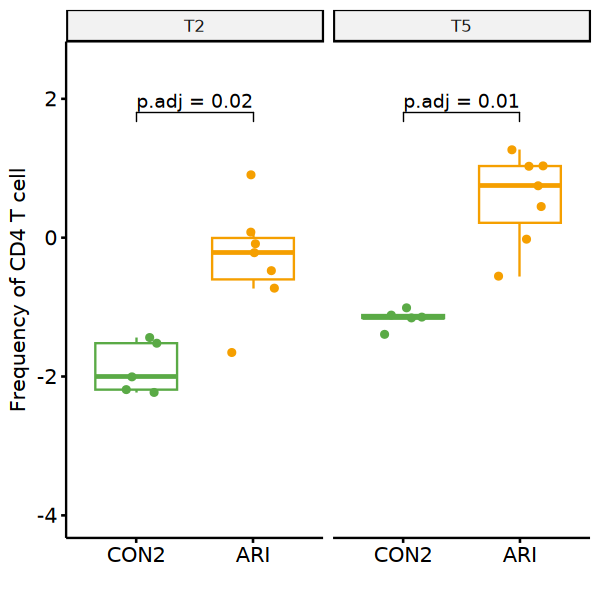

In [33]:
# plot the frequency compariosns for all the cluters
options(repr.plot.width = 5, repr.plot.height = 5)
p1 <- cluster_freq %>%
  filter(Clusters_0.8 %in% c("T2", "T5")) %>%
  ggpubr::ggboxplot(
    x = "cohort", y = "clr",
    xlab = "", ylab = "Frequency of CD4 T cell",
    palette = ari_colors,
    add = "jitter", color = "cohort"
  ) +
  facet_wrap(vars(factor(Clusters_0.8, levels = paste0("T", 1:11)))) + ylim(-4, 2.5) +
  guides(color = "none")
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
  filter(Clusters_0.8 %in% c("T2", "T5")) %>%
  add_xy_position(x = "cohort") %>%
  mutate(p.adj = round(p.adj, digits = 2))
p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
  label = "p.adj = {p.adj}",
  y.position = 1.8
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_C2C5_clr.pdf")), width = 5, height = 5)

### plot fig S12A

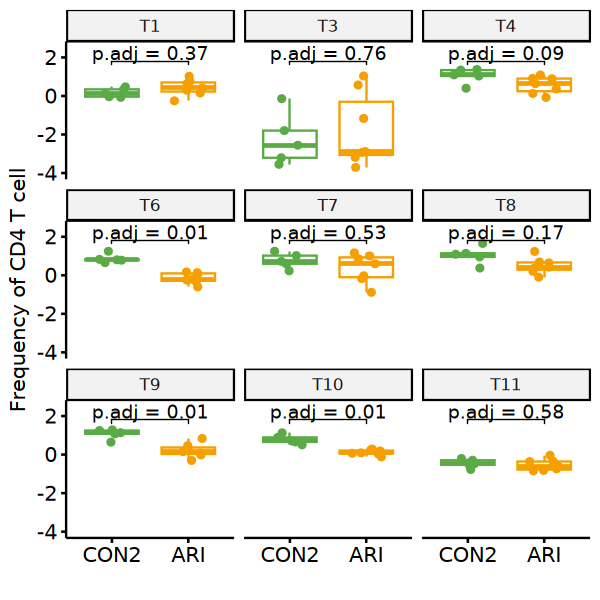

In [34]:
# plot the frequency compariosns for all the cluters
options(repr.plot.width = 5, repr.plot.height = 5)
p1 <- cluster_freq %>%
  filter(!Clusters_0.8 %in% c("T2", "T5")) %>%
  ggpubr::ggboxplot(
    x = "cohort", y = "clr",
    xlab = "", ylab = "Frequency of CD4 T cell",
    palette = ari_colors,
    add = "jitter", color = "cohort"
  ) +
  facet_wrap(vars(factor(Clusters_0.8, levels = paste0("T", 1:11)))) + ylim(-4, 2.5) +
  guides(color = "none")
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
  filter(!Clusters_0.8 %in% c("T2", "T5")) %>%
  add_xy_position(x = "cohort") %>%
  mutate(p.adj = round(p.adj, digits = 2))
p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
  label = "p.adj = {p.adj}",
  y.position = 1.8
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_nonsig_clr.pdf")), width = 5, height = 5)

In [35]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] data.table_1.15.4 rstatix_0.7.2     lubridate_1.9.4   forcats_1.0.0    
 [5] stringr_1.5.1     dplyr_1.1.4       purrr_1.0.2       readr_2.1.5      
 [9] tidyr_1.3.1       tibble_3.2.1      ggplot2_3.5.1     tidyverse_2.0.0  

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    strin